# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np


# Package untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Package untuk cleaning, modelling, dan evaluation model
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler, normalize, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [2]:
data = pd.read_csv('synthetic_beverage_sales.csv')
data.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,8/23/2023
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,8/23/2023
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,8/23/2023
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,8/23/2023
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,8/23/2023


In [3]:
data.tail()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
29994,ORD10060,CUS4955,B2C,Riesling,Alcoholic Beverages,4.19,11,0.0,46.09,Bremen,4/11/2022
29995,ORD10060,CUS4955,B2C,Evian,Water,1.26,9,0.0,11.34,Bremen,4/11/2022
29996,ORD10060,CUS4955,B2C,Schwip Schwap,Soft Drinks,1.24,1,0.0,1.24,Bremen,4/11/2022
29997,ORD10061,CUS8244,B2C,Schwip Schwap,Soft Drinks,1.27,2,0.0,2.54,Hessen,3/9/2023
29998,ORD10061,CUS8244,B2C,Hohes C Orange,Juices,1.86,9,0.0,16.74,Hessen,3/9/2023


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
data.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Type', 'Product', 'Category',
       'Unit_Price', 'Quantity', 'Discount', 'Total_Price', 'Region',
       'Order_Date'],
      dtype='object')

C:\Users\user\AppData\Local\Temp\ipykernel_13600\2265550436.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[num[i]], color='green')
C:\Users\user\AppData\Local\Temp\ipykernel_13600\2265550436.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[num[i]], color='green')
C:\Users\user\

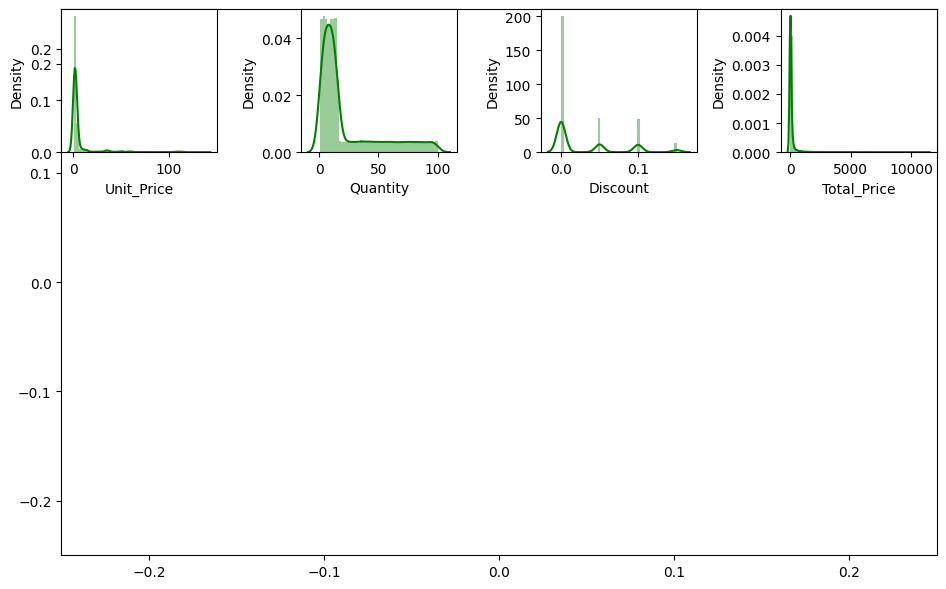

In [5]:
fig, ax = plt.subplots(figsize=(10,6))
plt.margins(2.0)
num = data.select_dtypes(include=['int64', 'float64']).columns
for i in range(0, len(num)):
    plt.subplot(3,4, i+1)
    sns.distplot(data[num[i]], color='green')
    plt.tight_layout()
plt.show()

In [6]:
data['Total_Price'].value_counts()

Total_Price
12.48     85
13.86     75
3.72      72
9.36      61
3.21      60
          ..
32.38      1
100.19     1
170.98     1
81.14      1
126.36     1
Name: count, Length: 8711, dtype: int64

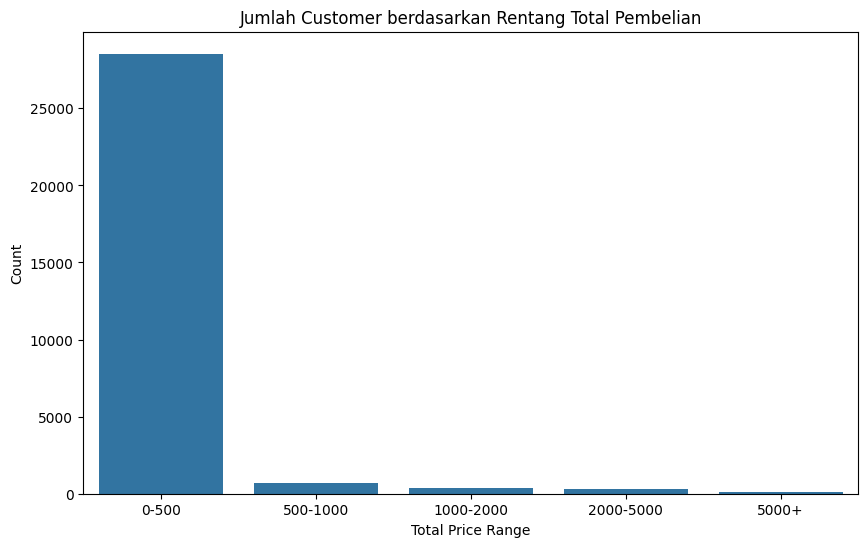

In [7]:
data["Total_Price_Binned"] = pd.cut(data["Total_Price"], bins=[0, 500, 1000, 2000, 5000, 10000], labels=["0-500", "500-1000", "1000-2000", "2000-5000", "5000+"])

plt.figure(figsize=(10, 6))
sns.countplot(data=data, x="Total_Price_Binned", order=data["Total_Price_Binned"].value_counts().index)
plt.title("Jumlah Customer berdasarkan Rentang Total Pembelian")
plt.xlabel("Total Price Range")
plt.ylabel("Count")
plt.show()

In [8]:
data.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Type', 'Product', 'Category',
       'Unit_Price', 'Quantity', 'Discount', 'Total_Price', 'Region',
       'Order_Date', 'Total_Price_Binned'],
      dtype='object')

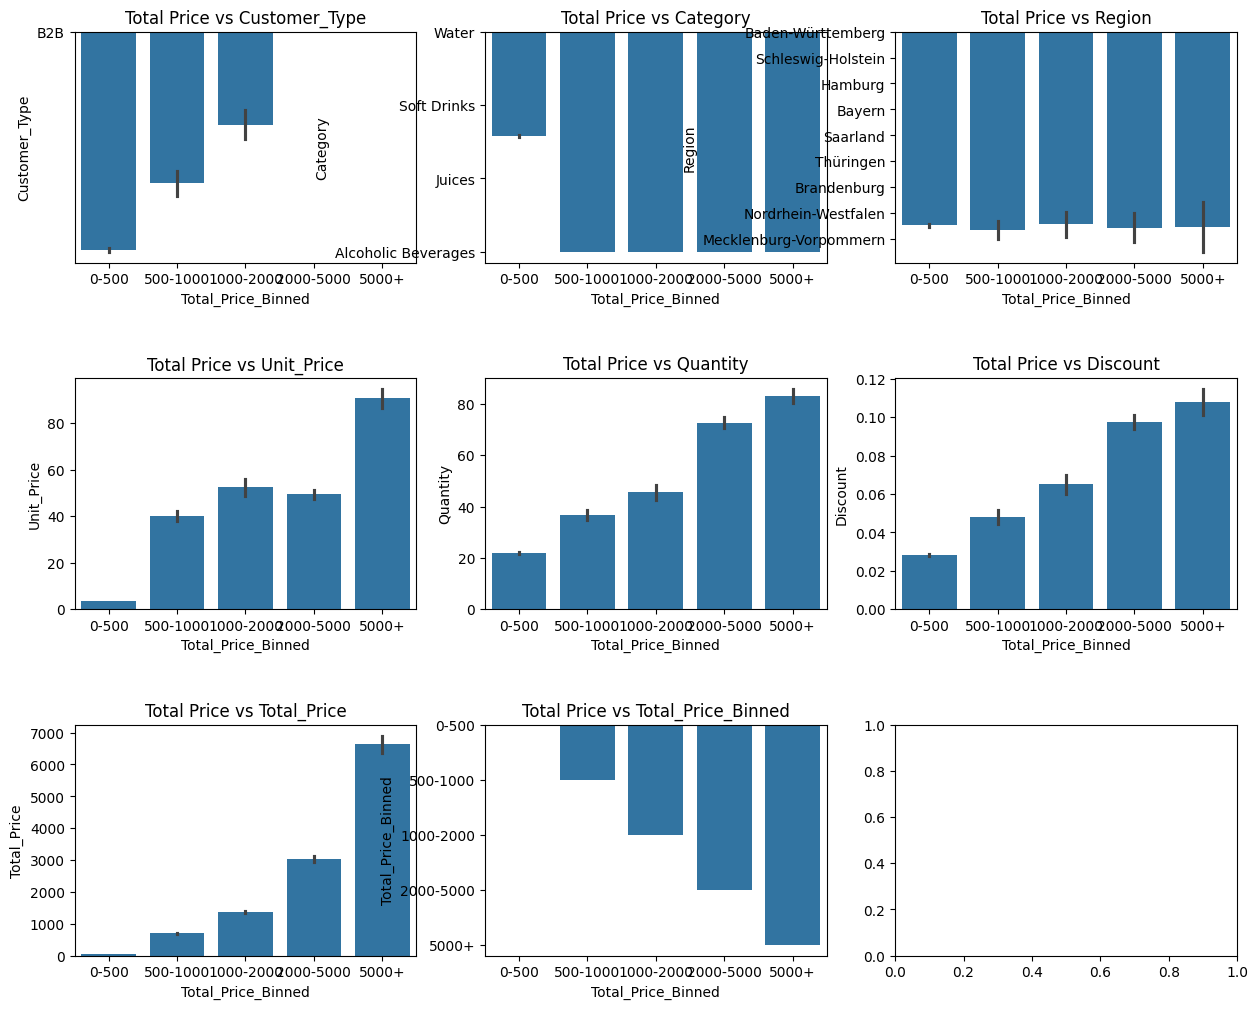

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # Atur jumlah subplot agar lebih rapi
plt.subplots_adjust(hspace=0.5)  # Beri jarak antar subplot

cols = ['Customer_Type', 'Category', 'Region' ,'Unit_Price' , 'Quantity', 'Discount', 'Total_Price','Total_Price_Binned']

for i, col in enumerate(cols):
    row, col_idx = divmod(i, 3)
    sns.barplot(data=data, x="Total_Price_Binned", y=col, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f"Total Price vs {col}")

plt.show()

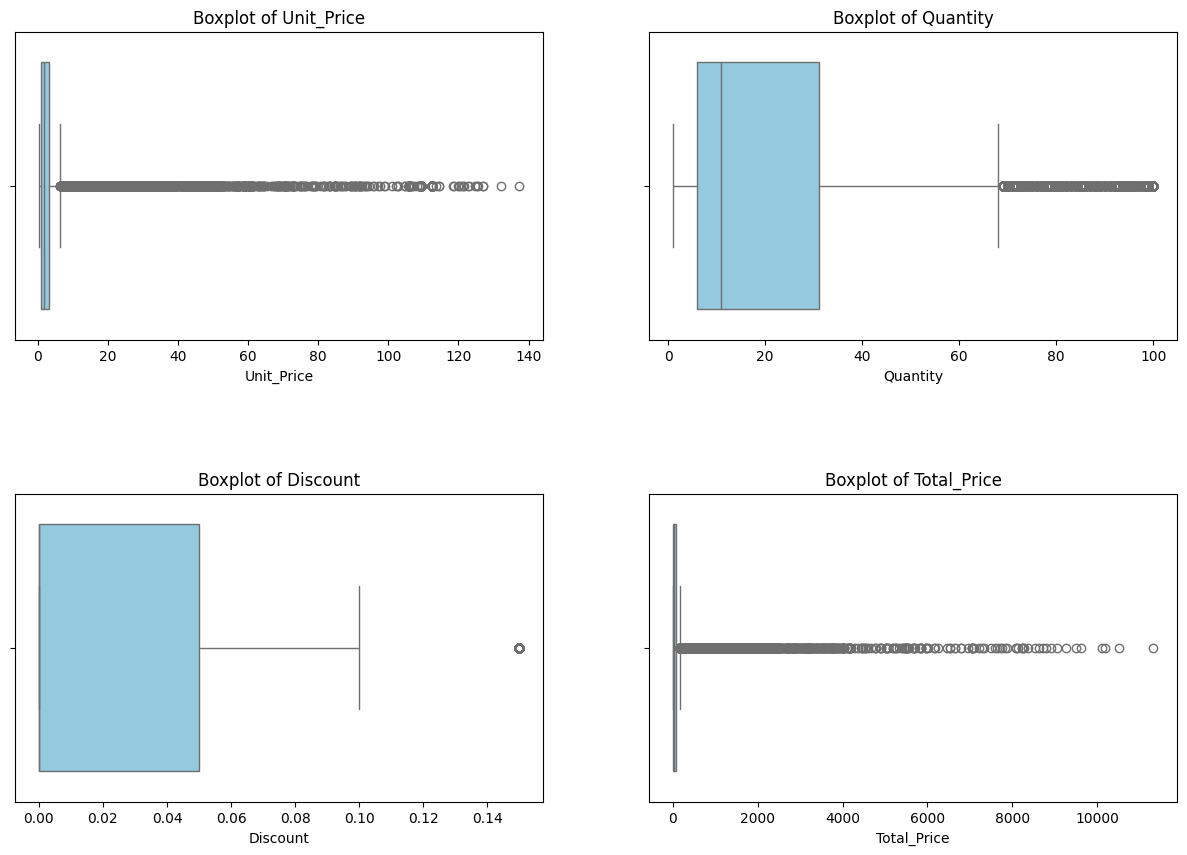

In [10]:
numeric_cols = ['Unit_Price', 'Quantity', 'Discount', 'Total_Price']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # Grid 2x2 untuk 4 variabel
plt.subplots_adjust(hspace=0.5)  # Jarak antar subplot

for i, col in enumerate(numeric_cols):
    row, col_idx = divmod(i, 2)  # Hitung posisi subplot
    sns.boxplot(data=data, x=col, ax=axes[row, col_idx], color="skyblue", orient='h')
    axes[row, col_idx].set_title(f"Boxplot of {col}")

plt.show()

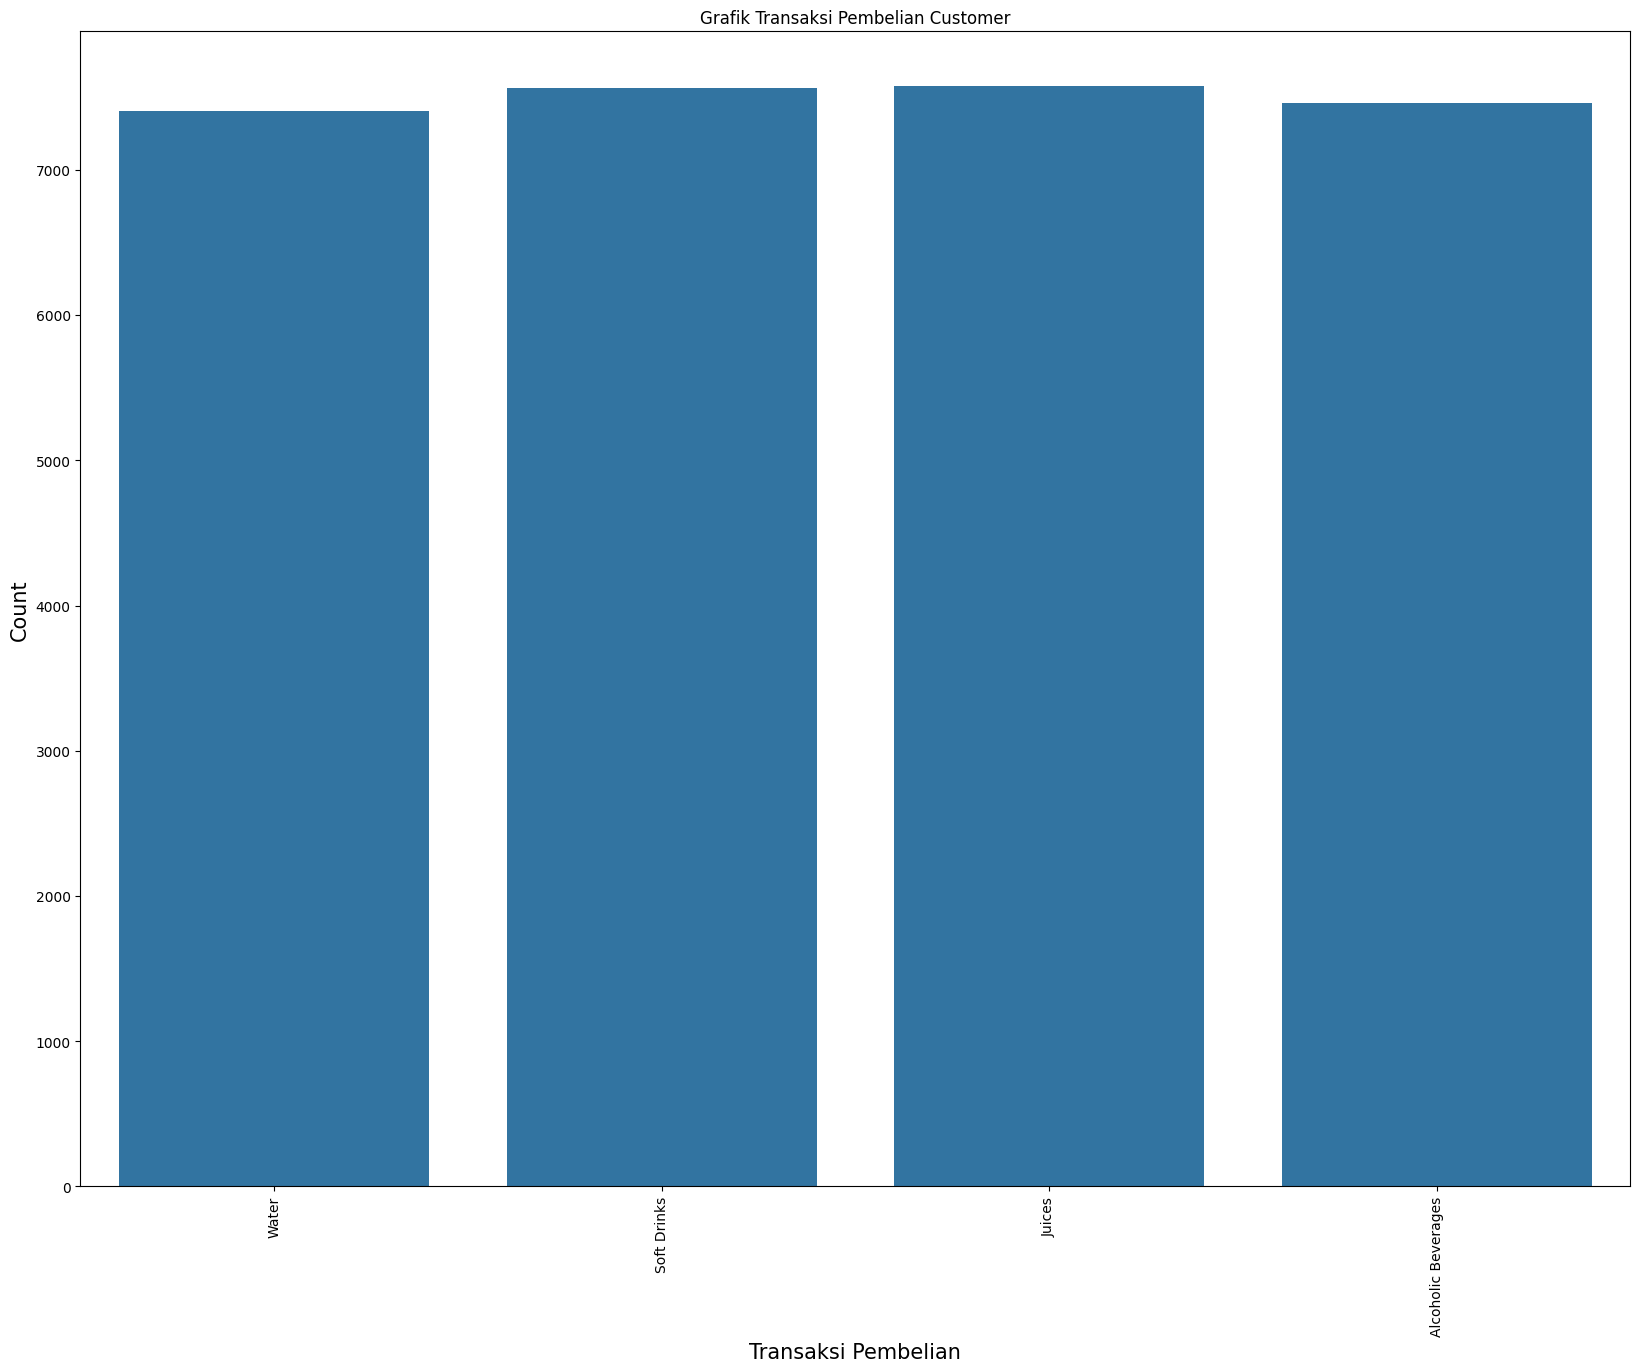

In [11]:
plt.figure(figsize=(20,15))
sns.countplot(data=data,x='Category')
plt.title('Grafik Transaksi Pembelian Customer')
plt.xlabel('Transaksi Pembelian',fontsize=15)
plt.xticks(rotation=90)
plt.ylabel('Count',fontsize=15)
plt.show()

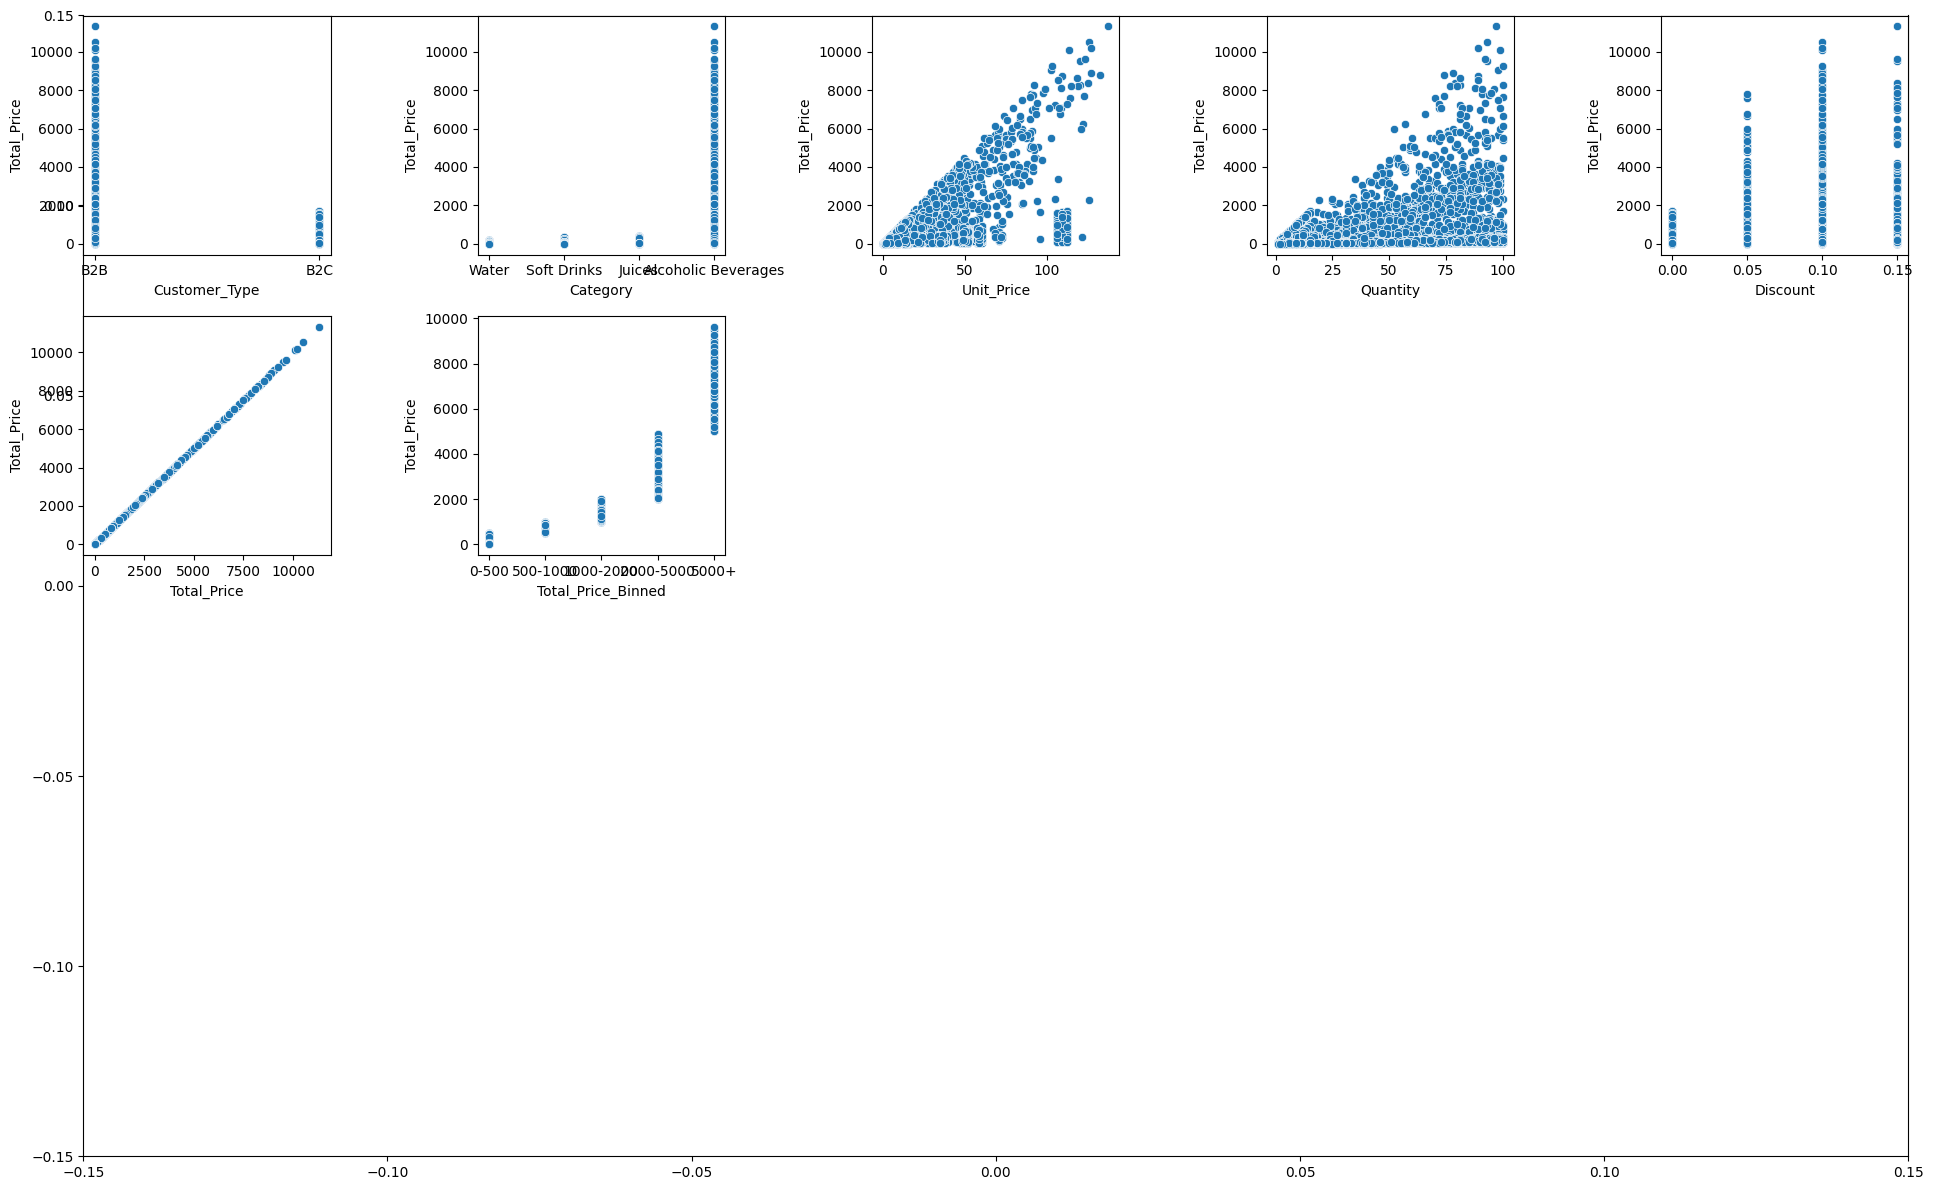

In [12]:
scatter_colomn = ['Customer_Type', 'Category' ,'Unit_Price' , 'Quantity',
                  'Discount', 'Total_Price','Total_Price_Binned']
fig, ax = plt.subplots(figsize=(20,12))
plt.margins(1.0)
for i in range(0, len(scatter_colomn)):
    plt.subplot(4,5, i+1)
    sns.scatterplot(x=data[scatter_colomn[i]], y=data['Total_Price'])
    plt.tight_layout()
plt.show()

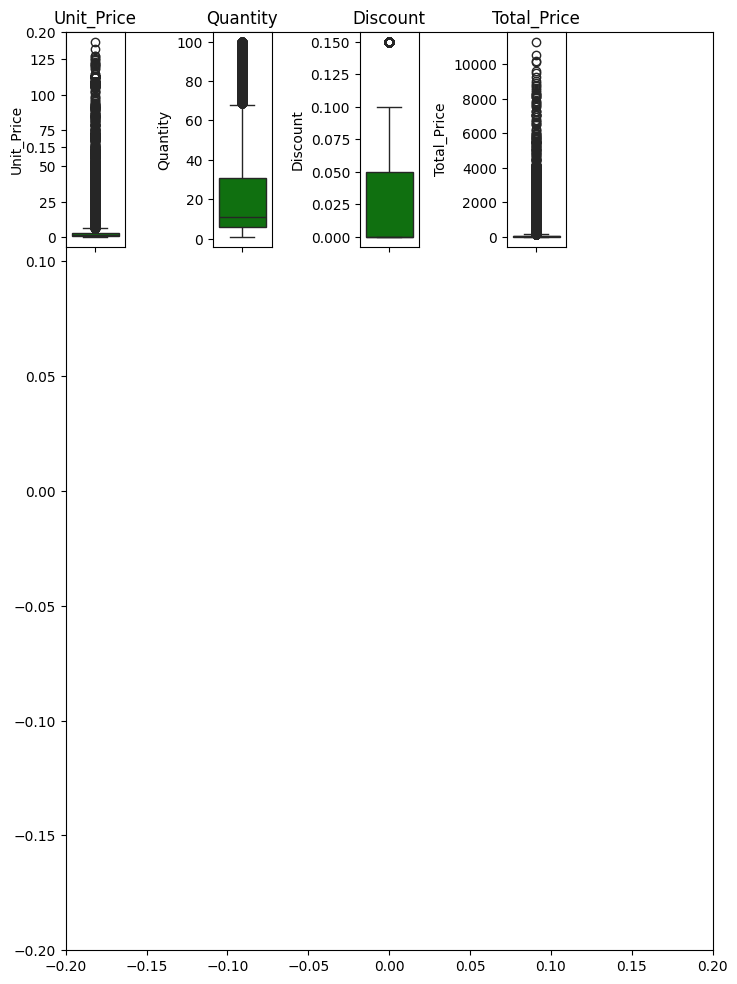

In [13]:
fig, ax = plt.subplots(figsize=(8,10))
plt.margins(1.5)
num = data.select_dtypes(include=['int64', 'float64']).columns
for i in range(0, len(num)):
    plt.subplot(4,5, i+1).set_title(num[i])
    sns.boxplot(y=data[num[i]], color='green')
    plt.tight_layout()
plt.show()

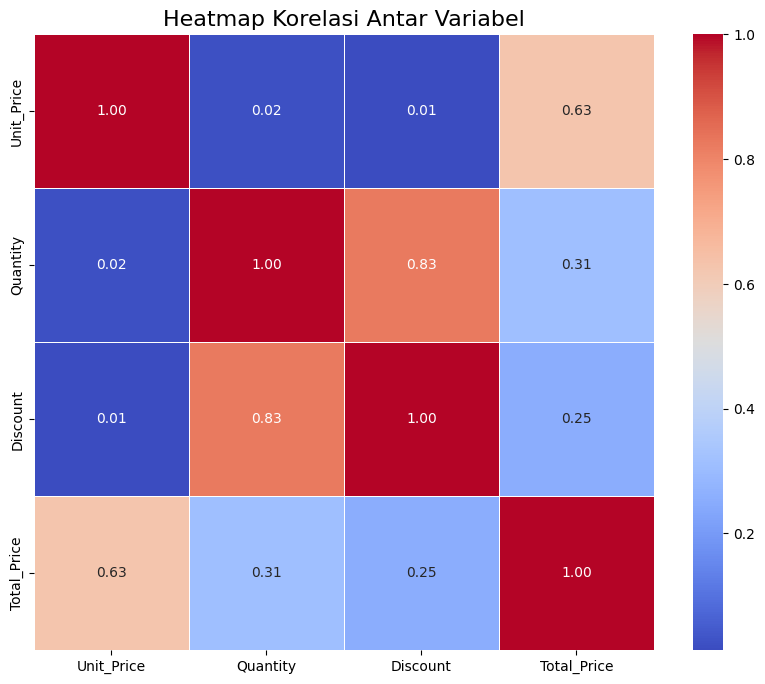

In [14]:
# Pilih hanya kolom numerik
numeric_data = data.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel', fontsize=16)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Order_ID            29999 non-null  object  
 1   Customer_ID         29999 non-null  object  
 2   Customer_Type       29999 non-null  object  
 3   Product             29999 non-null  object  
 4   Category            29999 non-null  object  
 5   Unit_Price          29999 non-null  float64 
 6   Quantity            29999 non-null  int64   
 7   Discount            29999 non-null  float64 
 8   Total_Price         29999 non-null  float64 
 9   Region              29999 non-null  object  
 10  Order_Date          29999 non-null  object  
 11  Total_Price_Binned  29995 non-null  category
dtypes: category(1), float64(3), int64(1), object(7)
memory usage: 2.5+ MB


In [16]:
data.describe()

,Unit_Price,Quantity,Discount,Total_Price
count,29999.000000,29999.000000,29999.000000,29999.000000
mean,5.733280,23.269776,0.030079,130.966205
std,14.635041,26.967314,0.045048,512.165599
min,0.320000,1.000000,0.000000,0.380000
25%,1.060000,6.000000,0.000000,8.520000
50%,1.750000,11.000000,0.000000,21.140000
75%,3.200000,31.000000,0.050000,68.720000
max,137.360000,100.000000,0.150000,11325.330000


In [17]:
data.describe(include='object')

,Order_ID,Customer_ID,Customer_Type,Product,Category,Region,Order_Date
count,29999,29999,29999,29999,29999,29999,29999
unique,10061,6384,2,47,4,16,1094
top,ORD1,CUS3265,B2C,Hohes C Orange,Juices,Hamburg,3/24/2021
freq,5,20,19206,1107,7574,2055,67


In [18]:
#Menghapus atau Menangani Data Kosong (Missing Values)
data.dropna(inplace=True)  # Menghapus baris dengan nilai NaN

In [19]:
# Menghapus Data Duplikat
data.drop_duplicates(inplace=True)

In [20]:
# Normalisasi atau Standarisasi Fitur
numerical_cols = ['Unit_Price', 'Quantity', 'Discount', 'Total_Price']
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

In [21]:
# Deteksi dan Penanganan Outlier (menggunakan metode Z-Score)
z_scores = np.abs(stats.zscore(data[numerical_cols]))
data = data[(z_scores < 3).all(axis=1)]

In [22]:
# Encoding Data Kategorikal
categorical_cols = ['Customer_Type', 'Category', 'Region']
encoder = LabelEncoder()
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

In [23]:
# Binning (Pengelompokan Data)
bin_labels = ['Low', 'Medium', 'High']
data['Total_Price_Binned'] = pd.qcut(data['Total_Price'], q=3, labels=bin_labels)

In [24]:
#Data setelah diproses
print(data.head())

  Order_ID Customer_ID  Customer_Type             Product  Category  \
0     ORD1     CUS1496              0          Vio Wasser         3   
1     ORD1     CUS1496              0               Evian         3   
2     ORD1     CUS1496              0              Sprite         2   
3     ORD1     CUS1496              0  Rauch Multivitamin         1   
4     ORD1     CUS1496              0        Gerolsteiner         3   

   Unit_Price  Quantity  Discount  Total_Price  Region Order_Date  \
0   -0.278476  1.103266  1.552676    -0.101229       0  8/23/2023   
1   -0.285340  2.475869  1.552676    -0.006465       0  8/23/2023   
2   -0.312108  1.845214  0.442538    -0.097292       0  8/23/2023   
3   -0.171403  1.325850  1.552676     0.083156       0  8/23/2023   
4   -0.332699  0.435513  1.552676    -0.205232       0  8/23/2023   

  Total_Price_Binned  
0               High  
1               High  
2               High  
3               High  
4             Medium  


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [25]:
X = data[numerical_cols]
y = data['Total_Price_Binned']
selector = SelectKBest(score_func=f_classif, k=3)
X_new = selector.fit_transform(X, y)
selected_features = np.array(numerical_cols)[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: ['Quantity' 'Discount' 'Total_Price']


In [26]:
wcss = []  # Within-Cluster Sum of Squares
silhouette_scores = []
K_range = range(2, 11)  # Coba K dari 2 sampai 10 (tidak bisa 1 untuk silhouette score)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_new)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_new, kmeans.labels_))

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

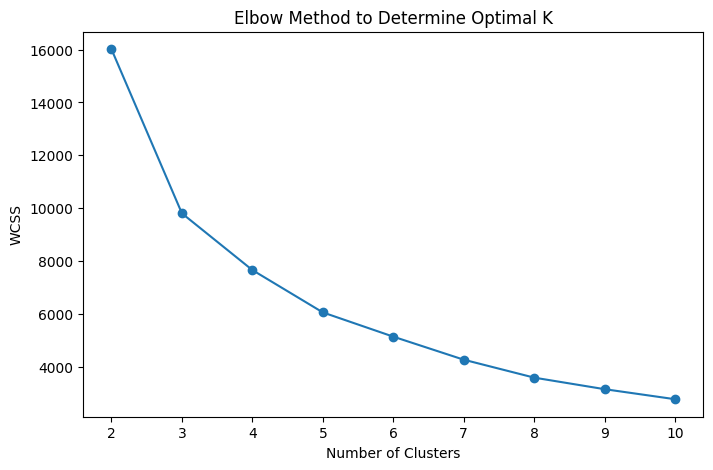

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method to Determine Optimal K')
plt.show()

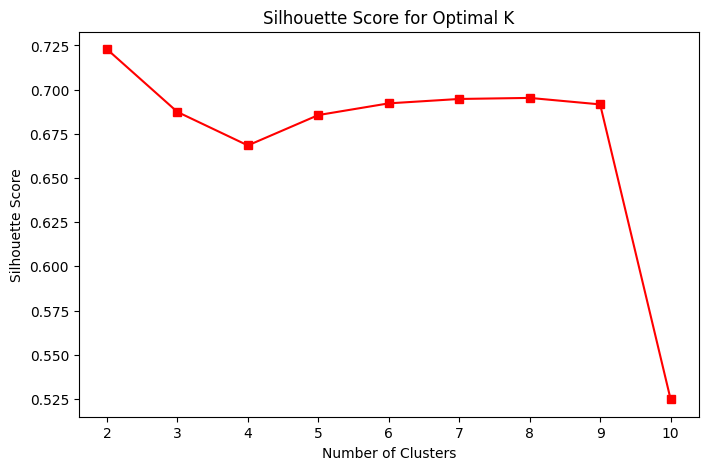

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='red')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.show()

In [29]:
optimal_k = 3  # Pilih berdasarkan Elbow Method dan Silhouette Score
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X_new)

## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [30]:
print("Selected Features:", selected_features)

Selected Features: ['Quantity' 'Discount' 'Total_Price']


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

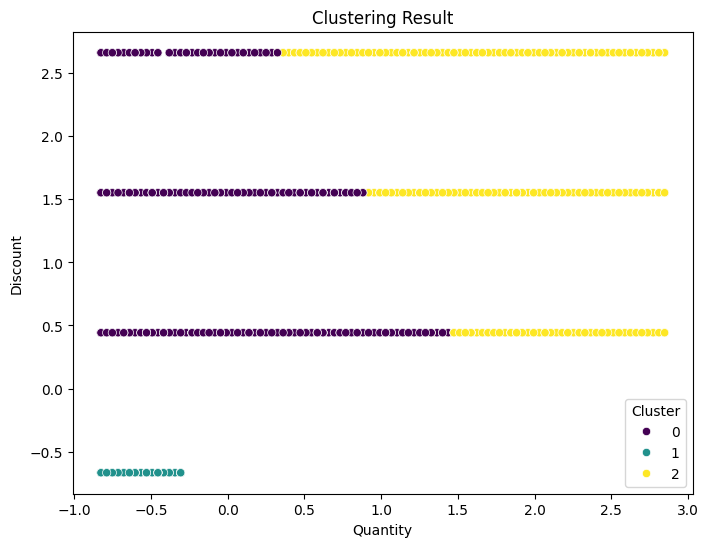

In [31]:
# Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data[selected_features[0]], y=data[selected_features[1]], hue=data['Cluster'], palette='viridis')
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.title('Clustering Result')
plt.show()

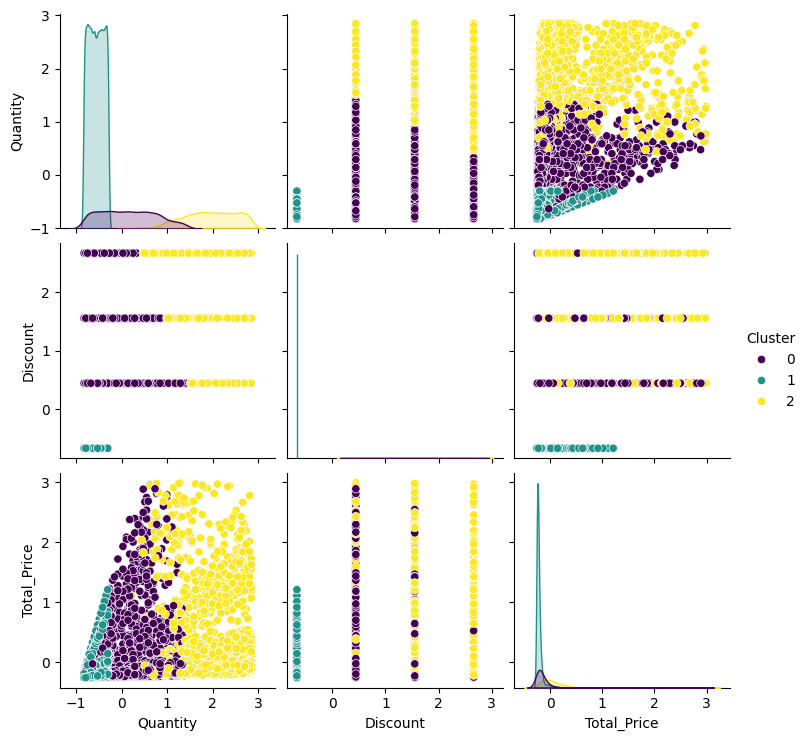

In [32]:
# Pairplot
sns.pairplot(data, hue='Cluster', vars=selected_features, palette='viridis')
plt.show()


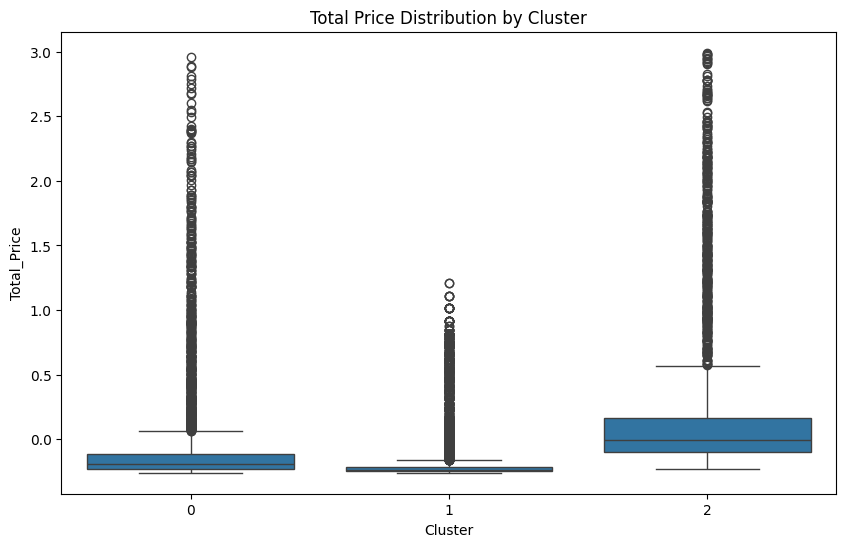

In [33]:
# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Total_Price', data=data)
plt.title('Total Price Distribution by Cluster')
plt.show()

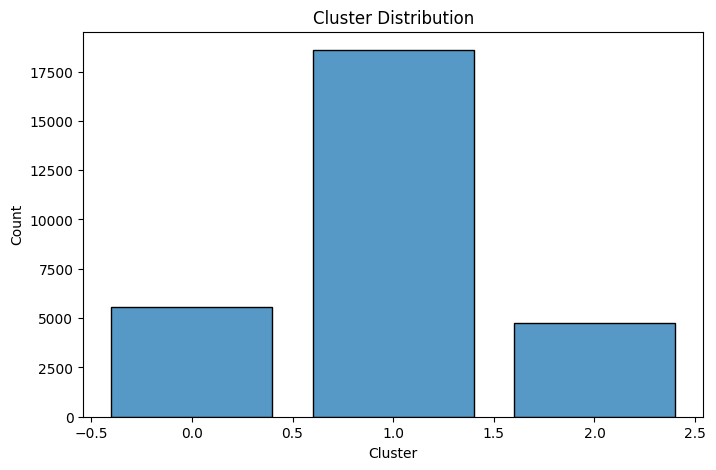

In [34]:
# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='Cluster', discrete=True, shrink=0.8, kde=False)
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Cluster Distribution')
plt.show()

In [35]:
# Menampilkan jumlah data dalam tiap cluster
print("Jumlah data dalam tiap cluster:")
print(data['Cluster'].value_counts())


Jumlah data dalam tiap cluster:
Cluster
1    18590
0     5559
2     4759
Name: count, dtype: int64


## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [36]:
# Assuming the k-means model was previously trained and assigned to the variable 'kmeans':
df_original = data.copy()  # Create a copy of the original DataFrame
df_normalized = data.copy()
df_normalized['Cluster'] = kmeans.labels_


In [54]:
label_encoder = LabelEncoder()

# Assuming 'Category' is the feature that was label encoded
# and should be inverse transformed:
df_normalized['Category'] = label_encoder.fit_transform(df_normalized['Category'])

# Now apply the inverse transform
df_normalized['Category'] = label_encoder.inverse_transform(df_normalized['Category'])

In [38]:
df_original['Category'] = df_normalized['Category']

### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [52]:
df_normalized[['Unit_Price', 'Quantity', 'Discount', 'Total_Price']] = scaler.inverse_transform(df_normalized[['Unit_Price', 'Quantity', 'Discount', 'Total_Price']])

In [50]:
# Evaluasi Model Clustering dengan Silhouette Score
silhouette_avg = silhouette_score(df_normalized[['Unit_Price', 'Quantity', 'Total_Price']], df_normalized['Cluster'])
print(f"\nSilhouette Score untuk Model KMeans dengan 3 Cluster: {silhouette_avg:.4f}")


Silhouette Score untuk Model KMeans dengan 3 Cluster: 0.2882


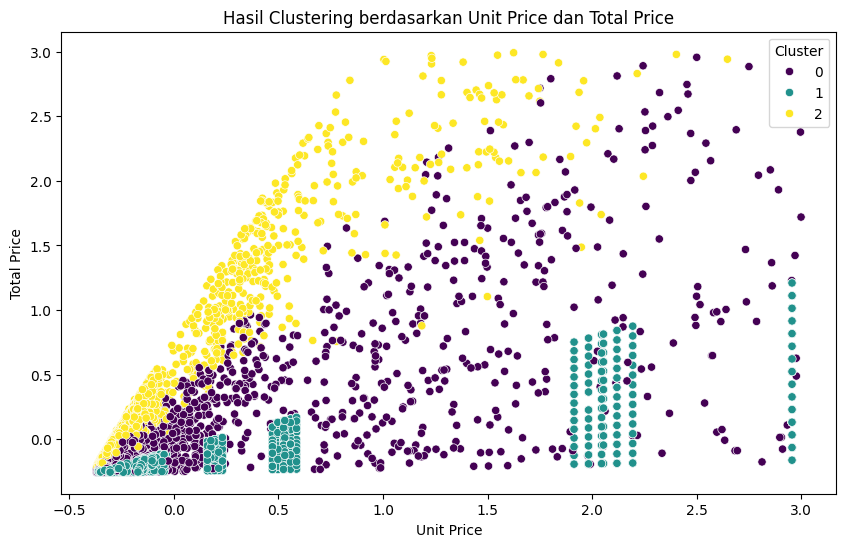

In [42]:
# Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Unit_Price', y='Total_Price', hue='Cluster', palette='viridis')
plt.title("Hasil Clustering berdasarkan Unit Price dan Total Price")
plt.xlabel("Unit Price")
plt.ylabel("Total Price")
plt.show()

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

## Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

In [ ]:
# Analisis Karakteristik Cluster 
cluster_summary = df_normalized.groupby('Cluster')[['Unit_Price', 'Quantity', 'Total_Price']].mean().reset_index()
print("\nAnalisis Karakteristik Cluster:")
for i, row in cluster_summary.iterrows():
    print(f"\n## Cluster {int(row['Cluster'])}:")
    print(f"- **Rata-rata Unit Price:** {row['Unit_Price']:.2f}")
    print(f"- **Rata-rata Quantity:** {row['Quantity']:.2f}")
    print(f"- **Rata-rata Total Price:** {row['Total_Price']:.2f}")
    print("- **Analisis:** Cluster ini menunjukkan pola pembelian pelanggan berdasarkan harga unit dan total pengeluaran.")


Analisis Karakteristik Cluster:

## Cluster 0:
- **Rata-rata Unit Price:** 869.71
- **Rata-rata Quantity:** 20400.51
- **Rata-rata Total Price:** 21243980.09
- **Analisis:** Cluster ini menunjukkan pola pembelian pelanggan berdasarkan harga unit dan total pengeluaran.

## Cluster 1:
- **Rata-rata Unit Price:** 801.50
- **Rata-rata Quantity:** 6467.92
- **Rata-rata Total Price:** 6742706.75
- **Analisis:** Cluster ini menunjukkan pola pembelian pelanggan berdasarkan harga unit dan total pengeluaran.

## Cluster 2:
- **Rata-rata Unit Price:** 741.11
- **Rata-rata Quantity:** 55642.99
- **Rata-rata Total Price:** 49609655.54
- **Analisis:** Cluster ini menunjukkan pola pembelian pelanggan berdasarkan harga unit dan total pengeluaran.


### Cluster 0:

- Rata-rata Unit Price:** 869.71
- Rata-rata Quantity:** 20400.51
- Rata-rata Total Price:** 21243980.09
- Analisis: Cluster ini menunjukkan pola pembelian pelanggan berdasarkan harga unit dan total pengeluaran. Cluster ini terdiri dari pelanggan yang membeli produk dengan harga unit dan total pengeluaran di bawah rata-rata, namun tetap membeli dalam jumlah normal. Mereka termasuk pembeli hemat yang sensitif terhadap harga. Rekomendasi strategi: tawarkan diskon kuantitas, bundling produk, atau promo cashback untuk meningkatkan nilai transaksi tanpa menaikkan harga per unit.

### Cluster 1:

- Rata-rata Unit Price:** 801.50
- Rata-rata Quantity:** 6467.92
- Rata-rata Total Price:** 6742706.75
- Analisis: Cluster ini menunjukkan pola pembelian pelanggan berdasarkan harga unit dan total pengeluaran. Pelanggan dalam cluster ini cenderung membeli produk dengan harga lebih murah dan total belanja lebih rendah, meski jumlah pembelian hampir normal. Mereka termasuk pembeli hemat yang cocok diberi penawaran paket hemat atau diskon untuk meningkatkan nilai transaksi.


### Cluster 2:

- Rata-rata Unit Price:** 741.11
- Rata-rata Quantity:** 55642.99
- Rata-rata Total Price:** 49609655.54
- Analisis: Cluster ini menunjukkan pola pembelian pelanggan berdasarkan harga unit dan total pengeluaran. Pelanggan dalam kelompok ini membeli produk dengan harga lebih murah  dan total belanja lebih rendah, meski jumlah pembelian normal. Mereka merupakan pembeli hemat yang ideal untuk penawaran paket diskon atau program loyalitas.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [58]:
# Simpan hasil clustering ke file CSV
data.to_csv("processed_clustering_result.csv", index=False)
print("Data hasil clustering telah disimpan.")

Data hasil clustering telah disimpan.
